# CAE for ECG Denoising
## Environment Setup

The Waveform Database (**WFDB**) is a set of open standards and software tools used to read, write, and process physiologic signals and annotations, such as **ECG** or EEG data. Primarily used for biomedical research and education, it is the **standard format for PhysioNet databases**

In [1]:
!pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 78.7 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.2 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you ha

## Importing the necessary Libraries

In [2]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt

## Data Exploration

### Importing Clean ECG and noises form Data Sources:


*   MIT-BIH Arrhythmia: https://physionet.org/content/mitdb/1.0.0/
*   MIT-BIH Noise Stress Test: https://physionet.org/content/nstdb/1.0.0/ (contains noise recordings)




### Load ECG (Arrhythmia Database)


*   Total records: 48
*   Each record ≈ one patient (or one recording session)
*   Numbered:<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;100, 101, 102, 103, 104, 105, 106, 107, 108, 109,<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;111, 112, 113, 114, 115, 116, 117, 118, 119,<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;121, 122, 123, 124,<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;200, 201, 202, 203,<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;205,<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;207, 208, 209, 210,<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;212, 213, 214, 215,<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;217,<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;219, 220, 221, 222, 223,<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;228,<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;230, 231, 232, 233, 234<br>



In [3]:
# wfdb.get_record_list('mitdb')

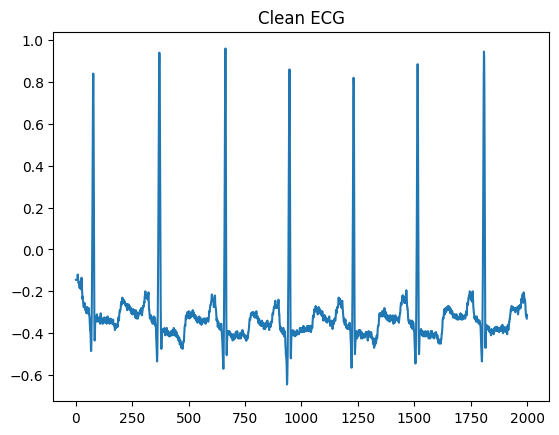

In [4]:
#Load patient number 100
record = wfdb.rdrecord('100', pn_dir='mitdb')

#Extract 1 ECG channel
signal = record.p_signal[:, 0]  # Lead II

#Visualize signal
plt.plot(signal[:2000])
plt.title("Clean ECG")
plt.show()

In [5]:
print(record.p_signal.shape) #(650000, 2) 650000 time samples, 2 leads (channels)
print(record.fs) #sampling frequency = 360 HZ
print(record.sig_name) #Names of ECG leads

(650000, 2)
360
['MLII', 'V5']


In [6]:
# record = wfdb.rdrecord('100', pn_dir='mitdb')

print("Shape:", record.p_signal.shape)
print("Sampling freq:", record.fs)
print("Signal names:", record.sig_name)
print("Units:", record.units)
print("Length:", record.sig_len)
print("Number of channels: ",record.n_sig)
print("ECG Signal values: ",record.p_signal[:,0])

Shape: (650000, 2)
Sampling freq: 360
Signal names: ['MLII', 'V5']
Units: ['mV', 'mV']
Length: 650000
Number of channels:  2
ECG Signal values:  [-0.145 -0.145 -0.145 ... -0.675 -0.765 -1.28 ]


In [7]:
ann = wfdb.rdann('100', 'atr', pn_dir='mitdb')
print("Indices of heartbeats: ",ann.sample[:5])
print("Type of beat: ",ann.symbol[:5])

Indices of heartbeats:  [ 18  77 370 662 946]
Type of beat:  ['+', 'N', 'N', 'N', 'N']


In [8]:
# ann.sample.shape
# len(ann.symbol)

In [9]:
# loop over 48 patients
records = [
'100','101','102','103','104','105','106','107','108','109',
'111','112','113','114','115','116','117','118','119','121',
'122','123','124',
'200','201','202','203','205','207','208','209',
'210','212','213','214','215','217','219',
'220','221','222','223','228','230','231','232','233','234'
]
#102,104,114 --> MLII not the first channel

record_number = 1
for r in records:
    record = wfdb.rdrecord(r, pn_dir='mitdb')
    print(f"Patient {record_number}: ECG signal name: {record.sig_name}, size: {record.sig_len}, number of channels: {record.n_sig}")
    record_number+=1

Patient 1: ECG signal name: ['MLII', 'V5'], size: 650000, number of channels: 2
Patient 2: ECG signal name: ['MLII', 'V1'], size: 650000, number of channels: 2
Patient 3: ECG signal name: ['V5', 'V2'], size: 650000, number of channels: 2
Patient 4: ECG signal name: ['MLII', 'V2'], size: 650000, number of channels: 2
Patient 5: ECG signal name: ['V5', 'V2'], size: 650000, number of channels: 2
Patient 6: ECG signal name: ['MLII', 'V1'], size: 650000, number of channels: 2
Patient 7: ECG signal name: ['MLII', 'V1'], size: 650000, number of channels: 2
Patient 8: ECG signal name: ['MLII', 'V1'], size: 650000, number of channels: 2
Patient 9: ECG signal name: ['MLII', 'V1'], size: 650000, number of channels: 2
Patient 10: ECG signal name: ['MLII', 'V1'], size: 650000, number of channels: 2
Patient 11: ECG signal name: ['MLII', 'V1'], size: 650000, number of channels: 2
Patient 12: ECG signal name: ['MLII', 'V1'], size: 650000, number of channels: 2
Patient 13: ECG signal name: ['MLII', 'V1

In [10]:
record_number = 1
for r in records[:5]:
    record = wfdb.rdrecord(r, pn_dir='mitdb')
    print(f"Patient {record_number}: ECG signal name: {record.sig_name}, values: {record.p_signal[:,0]}, integer values: {record.d_signal}")
    record_number+=1

Patient 1: ECG signal name: ['MLII', 'V5'], values: [-0.145 -0.145 -0.145 ... -0.675 -0.765 -1.28 ], integer values: None
Patient 2: ECG signal name: ['MLII', 'V1'], values: [-0.345 -0.345 -0.345 ... -0.295 -0.29   0.   ], integer values: None
Patient 3: ECG signal name: ['V5', 'V2'], values: [-0.2   -0.2   -0.2   ... -0.17  -0.195  0.   ], integer values: None
Patient 4: ECG signal name: ['MLII', 'V2'], values: [-0.375 -0.375 -0.375 ... -0.235 -0.245  0.   ], integer values: None
Patient 5: ECG signal name: ['V5', 'V2'], values: [-0.15  -0.15  -0.15  ... -0.065 -0.06   0.   ], integer values: None


### Load ECG (Noise Database)


1.   Baseline wander (bw) --> low-frequency, e.g. Breathing
2.   Muscle atrifact (ma) --> high-frequency, e.g. shivering
3.   Electrode movement (em)  → sudden spikes



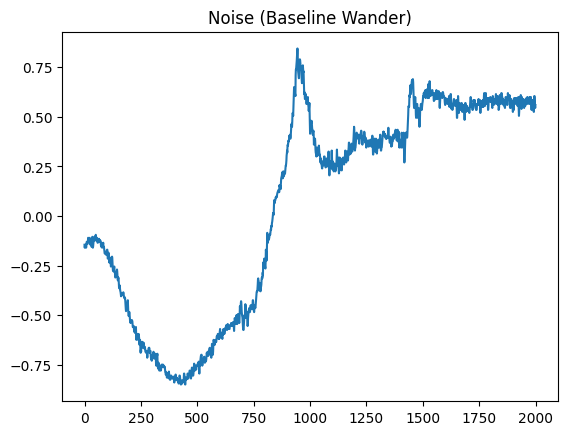

In [11]:
#Load baseline wander noise
noise_record = wfdb.rdrecord('bw', pn_dir='nstdb')  # baseline wander

#Extract signal
noise = noise_record.p_signal[:, 0]

#Visualize signal
plt.plot(noise[:2000])
plt.title("Noise (Baseline Wander)")
plt.show()

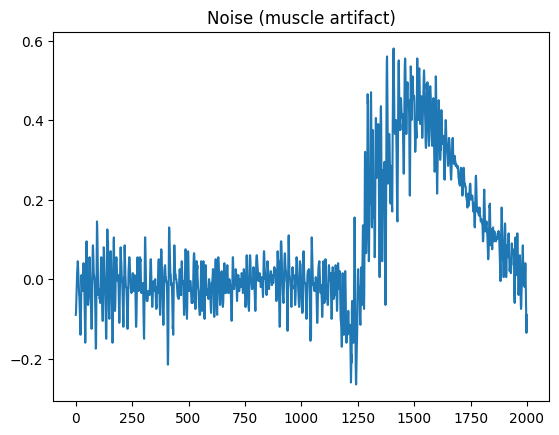

In [12]:
#Load muscle artifact  noise
noise_record = wfdb.rdrecord("ma", pn_dir="nstdb")  # muscle artifact

#Extract signal
noise = noise_record.p_signal[:, 0]

#Visualize signal
plt.plot(noise[:2000])
plt.title("Noise (muscle artifact)")
plt.show()

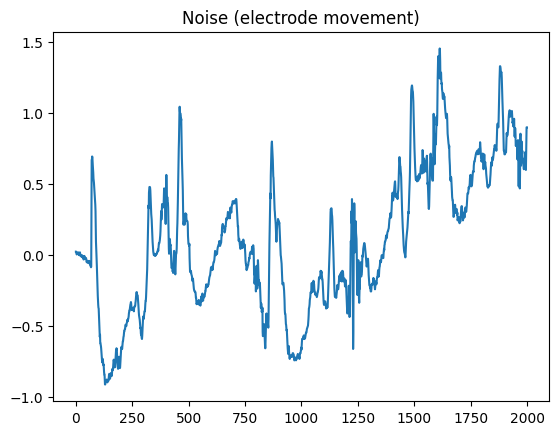

In [13]:
#Load electrode movement  noise
noise_record = wfdb.rdrecord("em", pn_dir="nstdb")  # electrode movement

#Extract signal
noise = noise_record.p_signal[:, 0]

#Visualize signal
plt.plot(noise[:2000])
plt.title("Noise (electrode movement)")
plt.show()

## Data Generation

*   Dividing records to training and testing
*   Using MLII channel only
*   Normalizing signals to be in range : -1 --> 1
*   Segmenting the signals for better processing based on the paper
*   Add noise to clean signals




###Train Test Split
* Inter-patient split (No patient appears in both sets) to avoid overfiting

* Avoid records 102, 104, 114 --> First channel is not MLII
* Work on MLII = Modified Lead II channel only, as it is the most informative and commonly used ECG lead

### Why MLII specifically?



1.   Best visibility of QRS complex
2.   Standard in research (for consistency and comparison with other papers)
3. Simpler model and less parameters






In [14]:
train_records = [
'101','106','108','109','112','115','116',
'118','119','122','124','201','203','205','207',
'208','209','215','220','223','230'
] # 21 patient

test_records = [
'100','103','105','111','113','117','121','123',
'200','202','210','212','213','214','219',
'221','222','228','231','232','233','234'
] # 20 patient

In [15]:
def load_ecg(record_name):
    record = wfdb.rdrecord(record_name, pn_dir='mitdb')
    signal = record.p_signal[:, 0]  # MLII
    return signal

In [16]:
def load_noise(noise_type):
    record = wfdb.rdrecord(noise_type, pn_dir='nstdb')
    return record.p_signal[:, 0]

### Normalization signal values [-1,1]
1. Stabilize the training
    - Smooth gradients
    - Faster convergence
2. Comparable with tanh output (autoencoder output)
3. Makes all patients comparable

In [17]:
def normalize(x):
    x = (x - np.min(x)) / (np.max(x) - np.min(x))
    return 2 * x - 1

### Signal segmentation based on the paper


*   Most of signals has ~ 650,000 samples, this too large for model and may cause memory issues

#### Solution

Split into windows of size = "2048" , each window contains multiple heartbeats "more than 5 cardiac cycles" <br>
All the values for the window size are based on the paper.



In [18]:
# Implementation of signal segmentation using a sliding window with a proportion of 1/2 to segment
# segment size = 2048, step/slide = 1/2 * 2048 = 1024
# This creates 50% overlap which makes transitions smooth and  better generalize
# output is (num_segments, 2048), number of segments for this signal, and each of size 2048
# since all signals are of length 650000, output (2592768, 2048)

def segment(signal, window=2048, step=1024):
    segments = []
    for i in range(0, len(signal) - window, step):
        segments.append(signal[i:i+window])
    return np.array(segments)

In [19]:
# record = wfdb.rdrecord("100", pn_dir='mitdb')
# segment(record.p_signal).size

### SNR-Based Noise Addition
We add it this way to control how noisy the signal is, So we adjust noise amplitude based on SNR value.

In the paper, there are 3 input SNR values, 0, 1.25, 5 db

In [20]:
def add_noise(clean, noise, snr_db):
    signal_power = np.mean(clean**2)
    noise_power = np.mean(noise**2)

    scale = np.sqrt(signal_power / (noise_power * 10**(snr_db/10)))
    return clean + scale * noise

### Noisy signals vs clean signals
Notes:


*   Only one type of noise is added at a time to learn the noise pattern efficiently, so the denoising module will be able to   
      - Learn BW removal
      - Learn MA removal
      - Generalize
*  Phase 1 (simple):
One noise type per segment,
Phase 2 (advanced / later): mixed noise types per segment (more realisitc)



In [21]:
def create_dataset(records, noise_bw, noise_ma, snr_levels=[0, 1.25, 5]):

    X, Y = [], []

    for r in records:
        signal = load_ecg(r)
        signal = normalize(signal)
        ecg_segments = segment(signal)

        bw_segments = segment(normalize(noise_bw))
        ma_segments = segment(normalize(noise_ma))

        for i in range(len(ecg_segments)):
            clean = ecg_segments[i]

            # randomly choose noise type
            if np.random.rand() > 0.5:
                noise = bw_segments[i % len(bw_segments)]
            else:
                noise = ma_segments[i % len(ma_segments)]

            snr = np.random.choice(snr_levels)
            noisy = add_noise(clean, noise, snr)

            X.append(noisy)
            Y.append(clean)

    return np.array(X), np.array(Y)

In [22]:
# Main Logic
bw_noise = load_noise('bw')
ma_noise = load_noise('ma')

In [23]:
X_train, Y_train = create_dataset(train_records, bw_noise, ma_noise)

### Using Permutation to shuffle sgeemnts
- Randomly shuffles dataset
- Keeps (X, Y) aligned
- Prevents overfitting to order, learn patient 1 segments then patient 2 segments in order and so on

In [24]:
# shuffle dataset
perm = np.random.permutation(len(X_train))
X_train, Y_train = X_train[perm], Y_train[perm]

# then DataLoader with shuffle=True

In [26]:
X_train.shape

(13293, 2048)

### Visualizing the clean vs noisy ECG

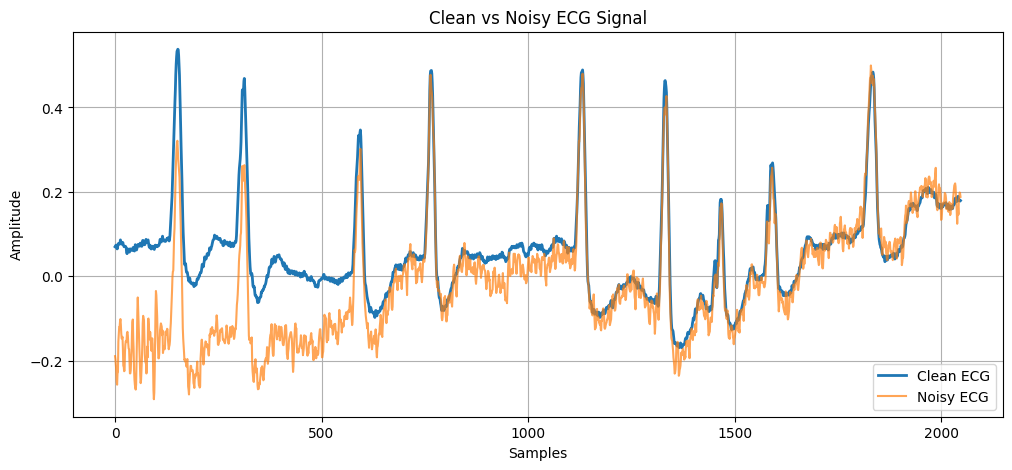

In [33]:
import matplotlib.pyplot as plt

# pick a sample index
i = 0

clean = Y_train[i]   # clean signal
noisy = X_train[i]   # noisy signal

plt.figure(figsize=(12,5))

plt.plot(clean, label="Clean ECG", linewidth=2)
plt.plot(noisy, label="Noisy ECG", alpha=0.7)

plt.title("Clean vs Noisy ECG Signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()

plt.show()

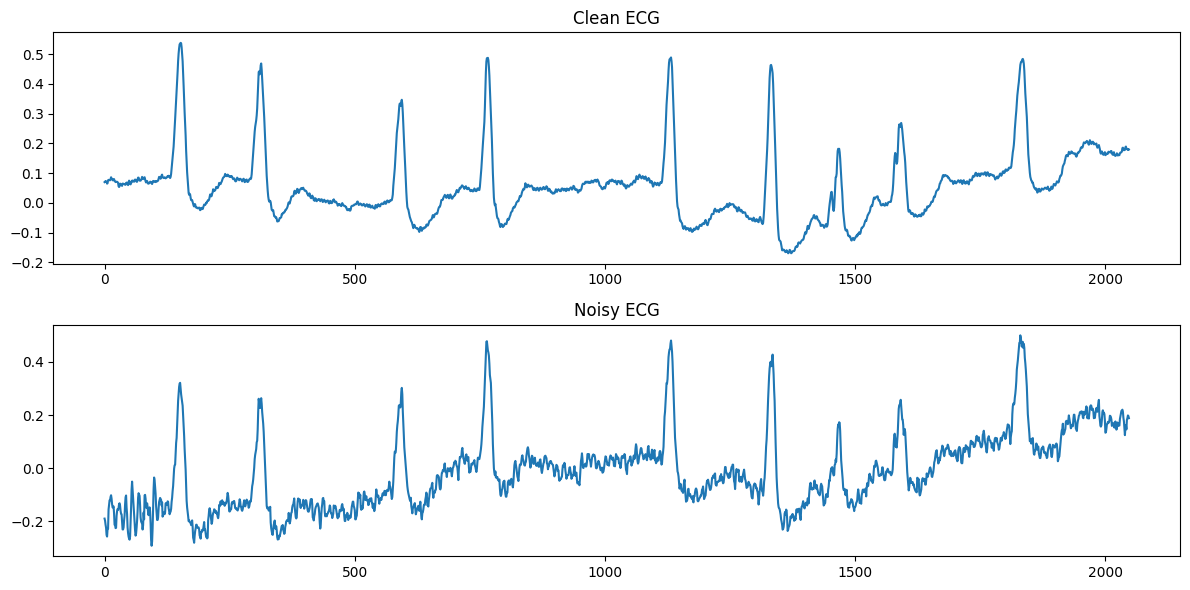

In [34]:
plt.figure(figsize=(12,6))

plt.subplot(2,1,1)
plt.plot(clean)
plt.title("Clean ECG")

plt.subplot(2,1,2)
plt.plot(noisy)
plt.title("Noisy ECG")

plt.tight_layout()
plt.show()

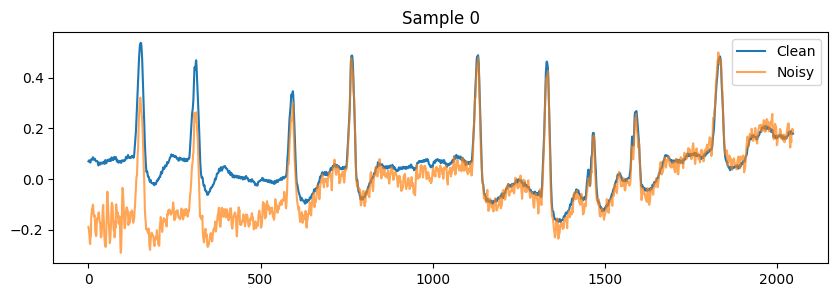

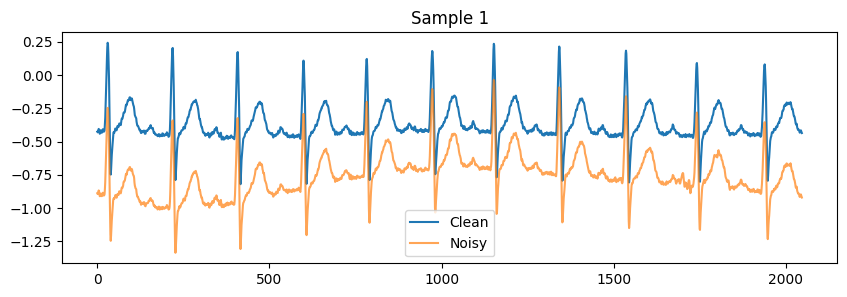

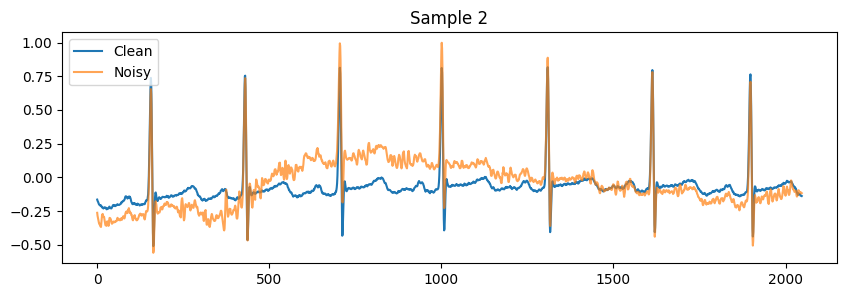

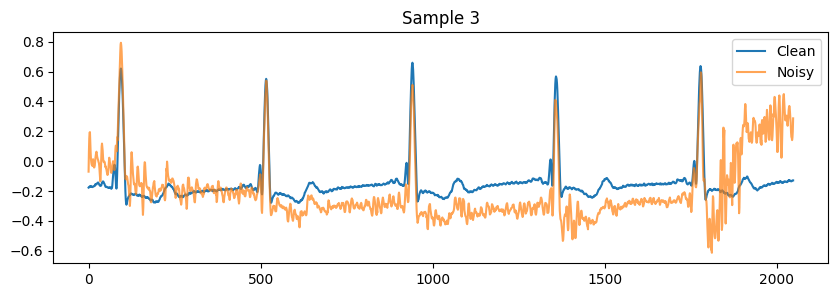

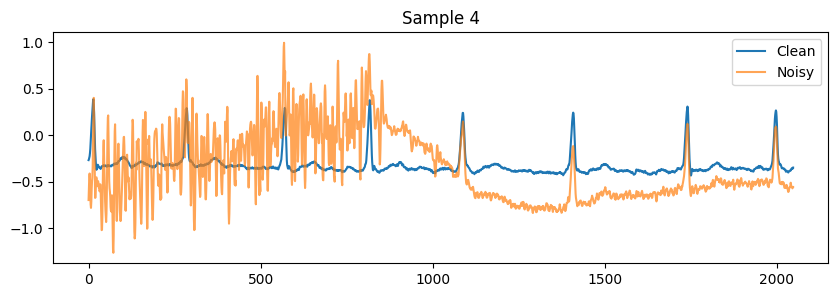

In [37]:
for i in range(5):
    plt.figure(figsize=(10,3))
    plt.plot(Y_train[i], label="Clean")
    plt.plot(X_train[i], label="Noisy", alpha=0.7)
    plt.legend()
    plt.title(f"Sample {i}")
    plt.show()

## AutoEncoder Implementation

In [44]:
import torch
import torch.nn as nn

class ECGAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        #Encoder
        self.enc1 = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        self.enc2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        # Dilated conv (SWT-inspired)
        self.dilated = nn.Conv1d(64, 64, kernel_size=3, padding=2, dilation=2)

        # Decoder
        self.up1 = nn.Upsample(scale_factor=2)
        self.dec1 = nn.Conv1d(64, 32, kernel_size=3, padding=1)

        self.up2 = nn.Upsample(scale_factor=2)
        self.dec2 = nn.Conv1d(32, 1, kernel_size=3, padding=1)

        self.tanh = nn.Tanh()

    def forward(self, x):
        # Encoder
        x1 = self.enc1(x)   # (B,32,1024)
        x2 = self.enc2(x1)  # (B,64,512)

        # Bottleneck
        x3 = self.dilated(x2)

        # Decoder + skip
        x = self.up1(x3)
        x = self.dec1(x + x1)   # skip connection

        x = self.up2(x)
        x = self.dec2(x)

        return self.tanh(x)

In [46]:
import torch.nn as nn

class ECGAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.enc1 = nn.Sequential(
            nn.Conv1d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2)   # → 1024
        )

        self.enc2 = nn.Sequential(
            nn.Conv1d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2)   # → 512
        )

        # Bottleneck (paper-inspired)
        self.dilated = nn.Conv1d(64, 64, 3, padding=2, dilation=2)

        # Decoder
        self.up1 = nn.Upsample(scale_factor=2)  # → 1024
        self.dec1 = nn.Conv1d(64, 32, 3, padding=1)

        self.up2 = nn.Upsample(scale_factor=2)  # → 2048
        self.dec2 = nn.Conv1d(32, 1, 3, padding=1)

        self.tanh = nn.Tanh()

    def forward(self, x):
        # Encoder
        x1 = self.enc1(x)   # (B,32,1024)
        x2 = self.enc2(x1)  # (B,64,512)

        # Bottleneck
        x3 = self.dilated(x2)

        # Decoder
        x = self.up1(x3)    # (B,64,1024)
        x = self.dec1(x)    # (B,32,1024)

        # FIX: match shape before skip
        x = x + x1          # skip connection works now

        x = self.up2(x)     # (B,32,2048)
        x = self.dec2(x)    # (B,1,2048)

        return self.tanh(x)

In [40]:
from torch.utils.data import DataLoader, TensorDataset
# main logic

X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
Y_train = torch.tensor(Y_train, dtype=torch.float32).unsqueeze(1)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = ECGAutoencoder().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


train_loader = DataLoader(
    TensorDataset(X_train, Y_train),
    batch_size=64,
    shuffle=True
)

In [41]:
print(X_train.shape)  # (N, 1, 2048)

torch.Size([13293, 1, 2048])


In [59]:
N_iter = 100
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = ECGAutoencoder().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(N_iter):
    model.train()
    total_loss = 0

    for noisy, clean in train_loader:
        noisy, clean = noisy.to(device), clean.to(device)

        pred = model(noisy)
        loss = criterion(pred, clean)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}: Loss = {total_loss:.4f}")

Epoch 1: Loss = 2.8217
Epoch 2: Loss = 2.1914
Epoch 3: Loss = 2.0389
Epoch 4: Loss = 2.0087
Epoch 5: Loss = 1.9778
Epoch 6: Loss = 1.9349
Epoch 7: Loss = 1.9238
Epoch 8: Loss = 1.8965
Epoch 9: Loss = 1.9078
Epoch 10: Loss = 1.8665
Epoch 11: Loss = 1.8830
Epoch 12: Loss = 1.8638
Epoch 13: Loss = 1.8705
Epoch 14: Loss = 1.8777
Epoch 15: Loss = 1.8601
Epoch 16: Loss = 1.8548
Epoch 17: Loss = 1.8523
Epoch 18: Loss = 1.8466
Epoch 19: Loss = 1.8520
Epoch 20: Loss = 1.8346
Epoch 21: Loss = 1.8225
Epoch 22: Loss = 1.8253
Epoch 23: Loss = 1.8250
Epoch 24: Loss = 1.8231
Epoch 25: Loss = 1.8264
Epoch 26: Loss = 1.8177
Epoch 27: Loss = 1.8219
Epoch 28: Loss = 1.8282
Epoch 29: Loss = 1.8271
Epoch 30: Loss = 1.8169
Epoch 31: Loss = 1.8032
Epoch 32: Loss = 1.8173
Epoch 33: Loss = 1.7990
Epoch 34: Loss = 1.8138
Epoch 35: Loss = 1.7999
Epoch 36: Loss = 1.8144
Epoch 37: Loss = 1.7941
Epoch 38: Loss = 1.8010
Epoch 39: Loss = 1.8030
Epoch 40: Loss = 1.8031
Epoch 41: Loss = 1.7945
Epoch 42: Loss = 1.7990
E

## Model Evaluation

In [60]:
import numpy as np

def compute_snr(clean, signal):
    return 10 * np.log10(
        np.sum(clean**2) / (np.sum((signal - clean)**2) + 1e-8)
    )

In [50]:
X_test, Y_test = create_dataset(test_records, bw_noise, ma_noise)

In [52]:
X_test  = torch.tensor(X_test,  dtype=torch.float32).unsqueeze(1)
Y_test  = torch.tensor(Y_test,  dtype=torch.float32).unsqueeze(1)

In [53]:
test_loader = DataLoader(
    TensorDataset(X_test, Y_test),
    batch_size=64,
    shuffle=False
)

In [61]:
model.eval()

snr_noisy_list = []
snr_denoised_list = []

with torch.no_grad():
    for noisy, clean in test_loader:
        noisy = noisy.to(device)
        clean = clean.numpy()

        denoised = model(noisy).cpu().numpy()
        noisy_np = noisy.cpu().numpy()

        for i in range(len(clean)):
            snr_noisy = compute_snr(clean[i,0], noisy_np[i,0])
            snr_denoised = compute_snr(clean[i,0], denoised[i,0])

            snr_noisy_list.append(snr_noisy)
            snr_denoised_list.append(snr_denoised)

print("Avg SNR (Noisy):", np.mean(snr_noisy_list))
print("Avg SNR (Denoised):", np.mean(snr_denoised_list))
print("Improvement:", np.mean(snr_denoised_list) - np.mean(snr_noisy_list))

Avg SNR (Noisy): 2.0695102
Avg SNR (Denoised): 8.540552
Improvement: 6.4710417


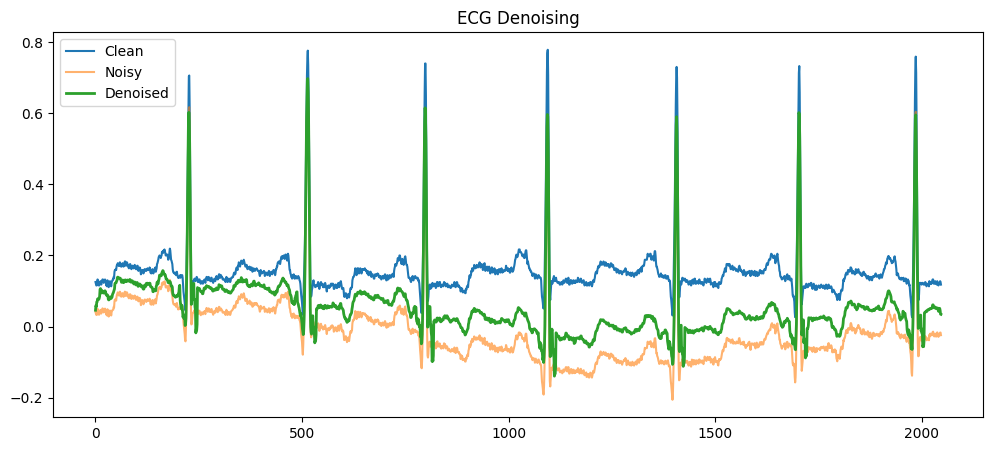

In [65]:
model.eval()

i = 5
noisy = X_test[i:i+1].to(device)

with torch.no_grad():
    denoised = model(noisy).cpu().numpy()[0,0]

clean = Y_test[i][0].numpy()
noisy = X_test[i][0].numpy()

plt.figure(figsize=(12,5))
plt.plot(clean, label="Clean")
plt.plot(noisy, label="Noisy", alpha=0.6)
plt.plot(denoised, label="Denoised", linewidth=2)
plt.legend()
plt.title("ECG Denoising")
plt.show()

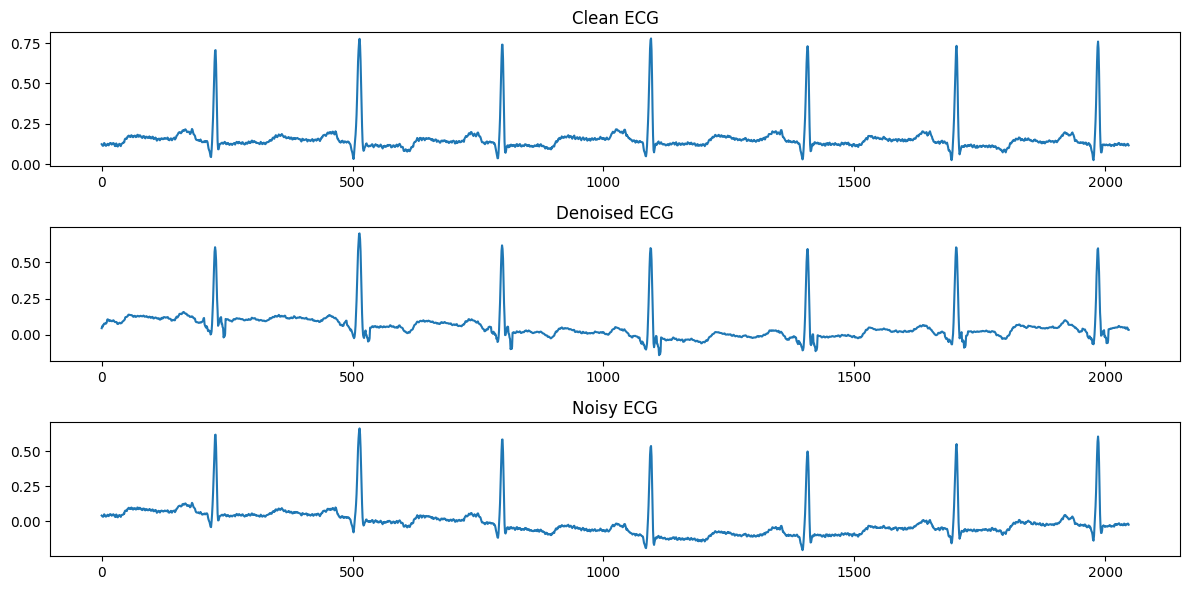

In [63]:
plt.figure(figsize=(12,6))

plt.subplot(3,1,1)
plt.plot(clean)
plt.title("Clean ECG")

plt.subplot(3,1,2)
plt.plot(denoised)
plt.title("Denoised ECG")

plt.subplot(3,1,3)
plt.plot(noisy)
plt.title("Noisy ECG")

plt.tight_layout()
plt.show()